In [6]:
# loading libraries

import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Suppress font-related warnings and set fallback font
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
sns.set(font='sans-serif')

Let's have a look at the layoffs in the tech world up to 2026 in comparison to the years before.

First step: loading the data

In [7]:
data = pd.read_csv("/Users/ulrike_imac_air/projects/DataScienceProjects/tech_layoffs/tech_layoffs_csv/tech_layoffs_til_2026.csv", delimiter=",")

print(data.columns)

Index(['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country',
       'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage',
       'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry',
       'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude'],
      dtype='str')


In [8]:
# Basic Dataset Insights
unique_companies = data['Company'].nunique()
unique_locations = data['Location_HQ'].nunique()
unique_countries = data['Country'].nunique()

print(f"Unique Companies: {unique_companies}")
print(f"Unique Locations: {unique_locations}")
print(f"Unique Countires: {unique_countries}")
unique_countries

Unique Companies: 1805
Unique Locations: 276
Unique Countires: 48


48

In [9]:
# Get unique countries and sort them alphabetically
unique_countries = sorted(data['Country'].unique())

# Print the list
unique_countries

['Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Brazil',
 'Canada',
 'Cayman Islands',
 'Chile',
 'China',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Hong Kong',
 'India',
 'Indonesia',
 'Ireland',
 'Israel',
 'Japan',
 'Kenya',
 'Lithuania',
 'Luxembourg',
 'Malaysia',
 'Malta',
 'Mexico',
 'Netherlands',
 'New Zealand',
 'Nigeria',
 'Norway',
 'Pakistan',
 'Poland',
 'Portugal',
 'Romania',
 'Russia',
 'Senegal',
 'Singapore',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Thailand',
 'United Arab Emirates',
 'United Kingdom',
 'United States',
 'Uruguay']

In [10]:
summary = pd.DataFrame({
    'Non-NA Count': data.count(),
    'NA Count': data.isna().sum()
})
print(summary)


                             Non-NA Count  NA Count
Nr                                   2592         0
Company                              2592         0
Location_HQ                          2592         0
Region                               2592         0
USState                              2591         1
Country                              2592         0
Continent                            2592         0
Laid_Off                             2154       438
Date_layoffs                         2592         0
Percentage                           2032       560
Company_Size_before_Layoffs          1805       787
Company_Size_after_layoffs           1893       699
Industry                             2592         0
Stage                                2428       164
Money_Raised_in__mil                 2048       544
Year                                 2592         0
latitude                             2592         0
longitude                            2592         0


In [11]:
# Drop rows with NaN in 'Laid_Off' column
data_cleaned = data.dropna(subset=['Laid_Off'])

# Verify the cleaned data
print(data_cleaned.shape)  # Check rows and columns

# Count non-NA values in the cleaned data
non_na_counts = data_cleaned.count()
print(non_na_counts)


(2154, 18)
Nr                             2154
Company                        2154
Location_HQ                    2154
Region                         2154
USState                        2153
Country                        2154
Continent                      2154
Laid_Off                       2154
Date_layoffs                   2154
Percentage                     1792
Company_Size_before_Layoffs    1792
Company_Size_after_layoffs     1790
Industry                       2154
Stage                          2044
Money_Raised_in__mil           1797
Year                           2154
latitude                       2154
longitude                      2154
dtype: int64


In [12]:
sum_laid_off = data_cleaned['Laid_Off'].sum()
print(sum_laid_off)

# Group by 'Year' and sum 'Laid_Off'
sum_laid_off_per_year = data_cleaned.groupby('Year')['Laid_Off'].sum().reset_index()
print(sum_laid_off_per_year)

869702.0
   Year  Laid_Off
0  2020   61529.0
1  2021    6790.0
2  2022  127577.0
3  2023  176946.0
4  2024  173522.0
5  2025  200445.0
6  2026  122893.0


In [13]:
# Statistical Analysis: Mean and Median Layoffs per Year
stats_per_year = data_cleaned.groupby('Year')['Laid_Off'].agg(['mean', 'median']).reset_index()
print("Mean and Median Layoffs per Year:")
print(stats_per_year)

# Interactive Boxplot of Layoffs per Year using Plotly
fig_box = px.box(data_cleaned, x='Year', y='Laid_Off', 
                 title='Distribution of Layoffs per Year (Boxplot)',
                 log_y=True) # Using log scale due to high variance
fig_box.show()

Mean and Median Layoffs per Year:
   Year         mean  median
0  2020   186.451515    63.0
1  2021   485.000000   170.0
2  2022   224.607394    84.5
3  2023   373.303797   100.0
4  2024   403.539535   100.0
5  2025   894.843750   121.0
6  2026  1078.008772   120.0


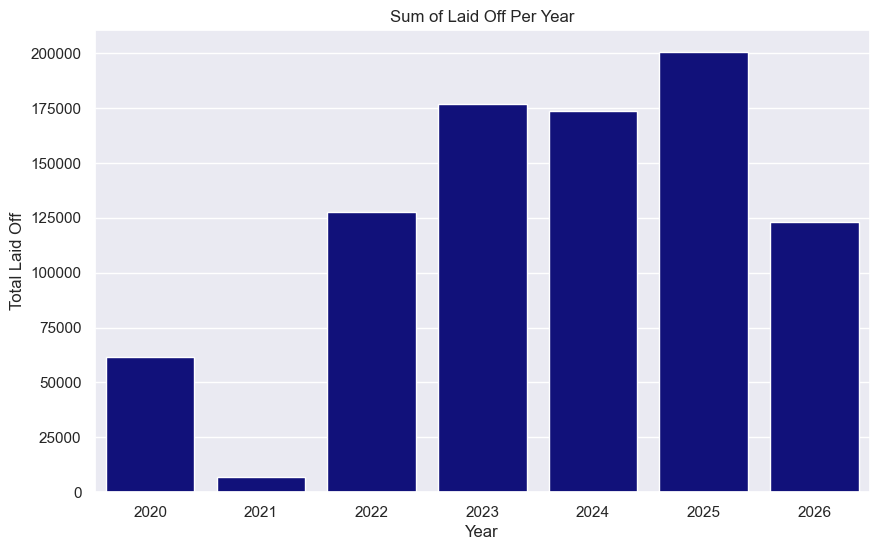

In [14]:
# Create a bar chart using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=sum_laid_off_per_year, x='Year', y='Laid_Off', color='darkblue')

# Add titles and labels
plt.title('Sum of Laid Off Per Year')
plt.xlabel('Year')
plt.ylabel('Total Laid Off')

# Show the plot
plt.show()

In [15]:
# Interactive Plotly bar chart showing layoffs per year
fig_bar = px.bar(sum_laid_off_per_year, x='Year', y='Laid_Off', 
                 title='Interactive: Sum of Laid Off Per Year', 
                 labels={'Laid_Off': 'Total Laid Off'},
                 color='Laid_Off', color_continuous_scale='plasma')
fig_bar.show()

Layoffs in tech remained high in 2024 and through to 2026, as seen in the visualizations.

In [16]:
# Group by 'Year' and 'Country' and sum 'Laid_Off'
sum_laid_off_per_year_country = data_cleaned.groupby(['Year', 'Country'])['Laid_Off'].sum().reset_index()

print(sum_laid_off_per_year_country.head())

   Year    Country  Laid_Off
0  2020  Australia      96.0
1  2020     Brazil    1227.0
2  2020     Canada     982.0
3  2020    Estonia      63.0
4  2020    Germany     331.0


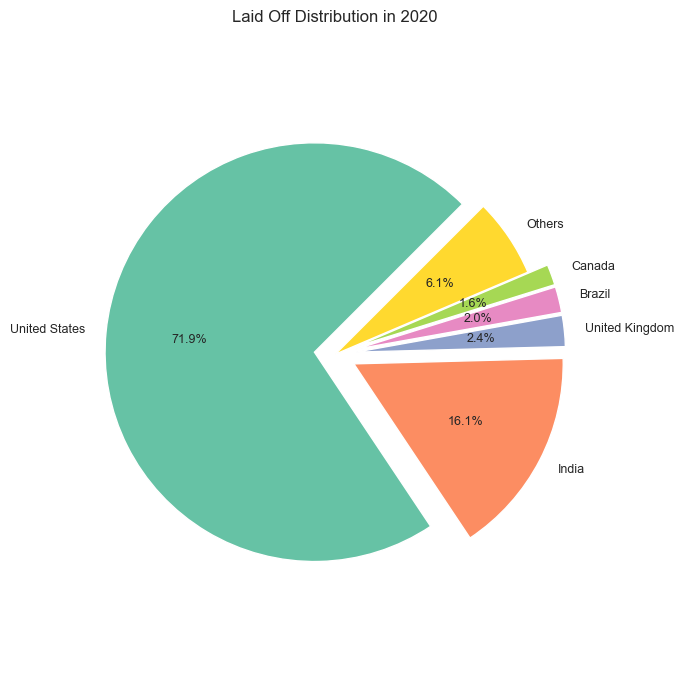

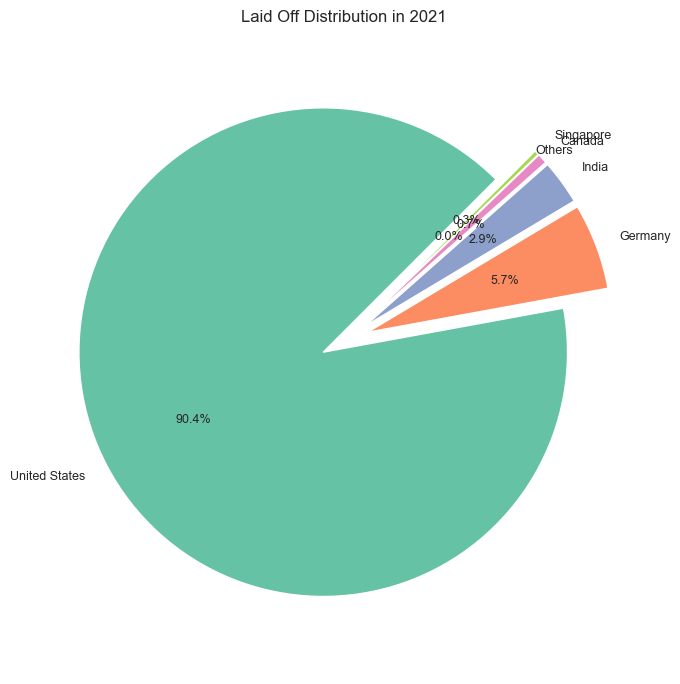

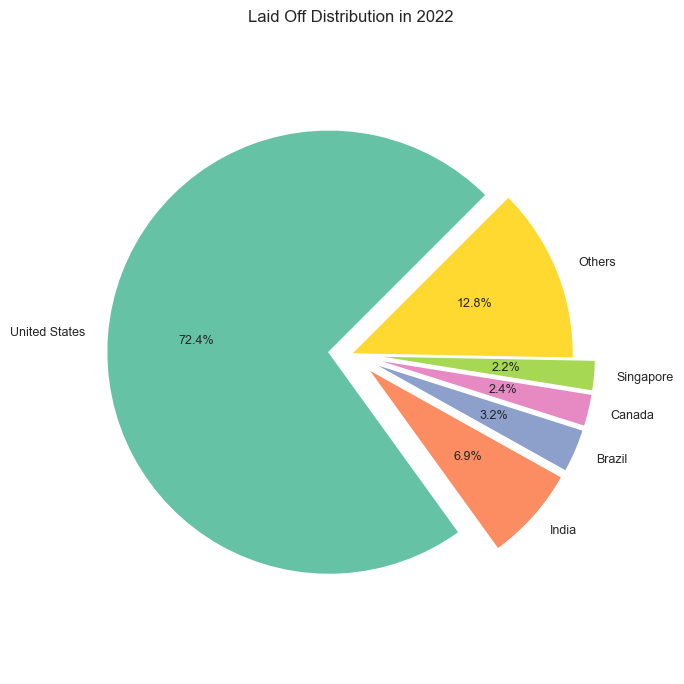

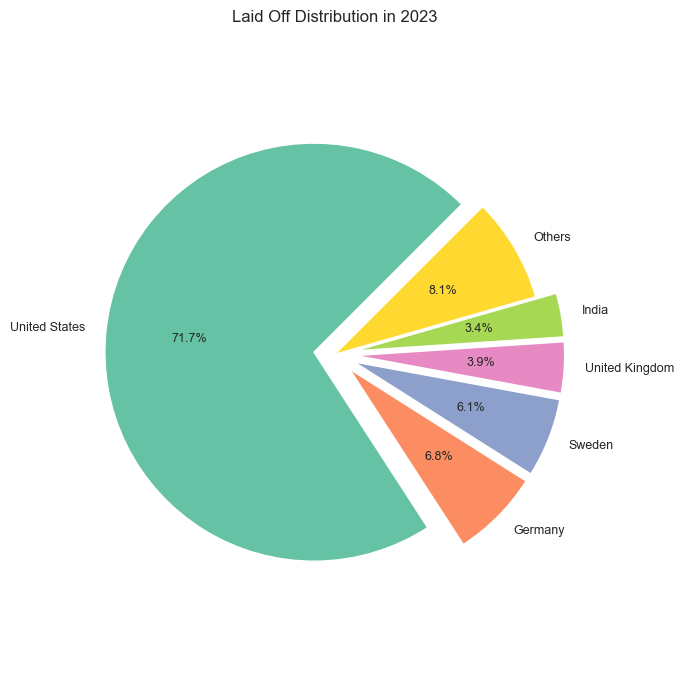

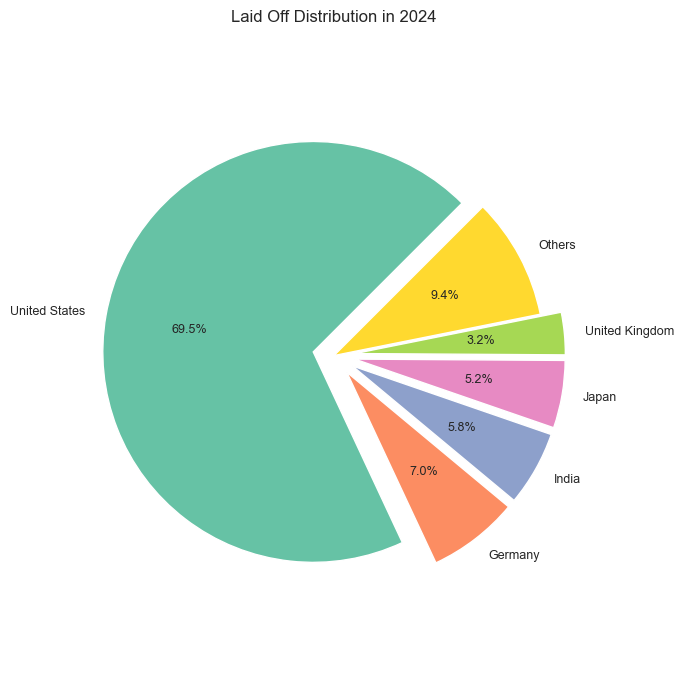

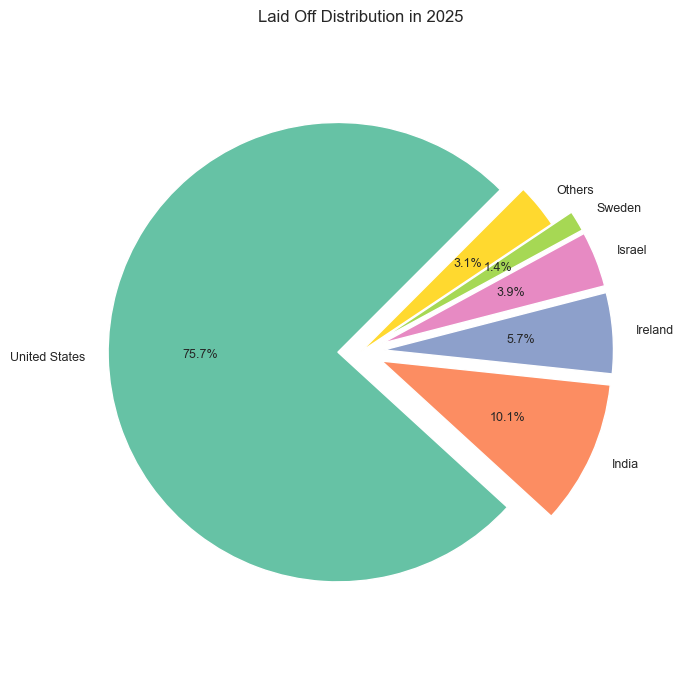

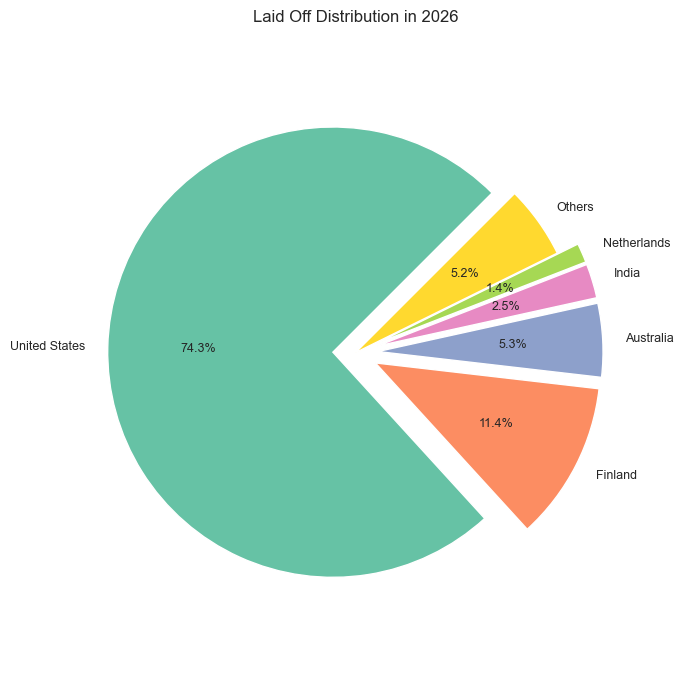

In [17]:
# Group by 'Year' and 'Country' and sum 'Laid_Off'
sum_laid_off_per_year_country = data_cleaned.groupby(['Year', 'Country'])['Laid_Off'].sum().reset_index()

# Get unique years
years = sum_laid_off_per_year_country['Year'].unique()

# Create a pie chart for each year
for year in years:
    # Filter data for the specific year
    year_data = sum_laid_off_per_year_country[sum_laid_off_per_year_country['Year'] == year]
    
    # Sort the data by 'Laid_Off' and get top 5 countries
    top_countries = year_data.nlargest(5, 'Laid_Off')
    
    # Get the remaining countries and sum their 'Laid_Off' values into "Others"
    others_sum = year_data[~year_data['Country'].isin(top_countries['Country'])]['Laid_Off'].sum()
    others = pd.DataFrame({'Country': ['Others'], 'Laid_Off': [others_sum]})
    
    # Combine top countries with "Others"
    final_data = pd.concat([top_countries, others])
    
    # Use Seaborn 'Set1' color palette
    colors = sns.color_palette('Set2', len(final_data))
    
    # Define 'explode' to slightly separate the largest slices (e.g., the top 5 countries)
    explode = [0.1 if country != 'Others' else 0 for country in final_data['Country']]

    # Plot the pie chart
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(final_data['Laid_Off'], labels=final_data['Country'], autopct='%1.1f%%', 
                                       startangle=45, colors=colors, explode=explode, labeldistance=1.1)

    # Adjust label font size
    for text in texts + autotexts:
        text.set_fontsize(9)

    plt.title(f'Laid Off Distribution in {year}')
    plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
    
    # Ensure the layout is adjusted so labels don't overlap
    plt.tight_layout()
    plt.show()

In [18]:
# Interactive Plotly sunburst chart: Continent -> Country -> Industry
fig_sunburst = px.sunburst(data_cleaned, 
                           path=['Continent', 'Country', 'Industry'], 
                           values='Laid_Off',
                           title='Layoffs Hierarchy: Continent -> Country -> Industry',
                           color='Continent')
fig_sunburst.show()

In [19]:
# Interactive Plotly scatter_geo map showing layoffs globally
# Grouping by Location to avoid overlapping bubbles in the animation
data_geo = data_cleaned.groupby(['Year', 'Country', 'latitude', 'longitude', 'Industry'])['Laid_Off'].sum().reset_index()

fig_geo = px.scatter_geo(data_geo, 
                         lat='latitude', 
                         lon='longitude', 
                         color='Country', 
                         hover_name='Country', 
                         size='Laid_Off', 
                         animation_frame='Year',
                         title='Global Tech Layoffs Over Time (2020-2026)',
                         projection='natural earth')
fig_geo.show()